In [469]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import PolyCollection
from matplotlib.collections import LineCollection
from matplotlib.path import Path
from matplotlib.patches import PathPatch

In [ ]:
def make_wavelength_intensity_cmap(
        wavelengths, intensities, wavelength_to_rgb,
        light_on_high=True, gamma=2.2, smooth_sigma=1.0
):
    """
    Build a colormap where:
    - hue comes from wavelength_to_rgb(w)
    - brightness comes from intensity**gamma
    - brightness is smoothed to avoid abrupt jumps around sharp peaks
    """

    # Normalize intensities to [0,1]
    inten_norm = mcolors.Normalize(vmin=np.min(intensities),
                                   vmax=np.max(intensities))(intensities)

    # Apply gamma for contrast
    bright = inten_norm ** gamma

    # Smooth brightness to soften transitions
    if smooth_sigma > 0:
        bright = scipy.ndimage.gaussian_filter1d(bright, sigma=smooth_sigma)

    # Re-normalize brightness after smoothing
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

    # Convert wavelength to RGB (strip alpha)
    base_rgb = np.array([tuple(wavelength_to_rgb(w))[:3] for w in wavelengths])

    # Convert to HSV to modify brightness only
    hsv = mcolors.rgb_to_hsv(base_rgb)

    if light_on_high:
        hsv[:, 2] = bright
    else:
        hsv[:, 2] = 1 - bright

    new_rgb = mcolors.hsv_to_rgb(hsv)
    return mcolors.ListedColormap(new_rgb)


def render_spectrum_image(
        wavelengths, intensities, wavelength_to_rgb,
        image_height=100, light_on_high=True, gamma=2.2,
        x_min=None, x_max=None, num_display_samples=1000,
        ax=None  # ← NEW
):
    """
    Render a horizontal spectrum image.
    Can render directly onto an existing axes if ax is provided.
    """

    if x_min is None:
        x_min = wavelengths.min()
    if x_max is None:
        x_max = wavelengths.max()

    wl_display = np.linspace(x_min, x_max, num_display_samples)
    inten_display = np.interp(wl_display, wavelengths, intensities)

    cmap_image = make_wavelength_intensity_cmap(
        wl_display, inten_display, wavelength_to_rgb,
        light_on_high=light_on_high, gamma=gamma, smooth_sigma=0
    )

    img = np.tile(np.arange(num_display_samples), (image_height, 1))

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 1.5))
        created_fig = True

    ax.imshow(img, cmap=cmap_image, aspect='auto', extent=[x_min, x_max, 0, 1])
    ax.set_yticks([])
    ax.set_xlabel("Wavelength (nm)")

    if created_fig:
        return fig, ax
    else:
        return ax


fig, ax = render_spectrum_image(wavelengths, intensities, wavelength_to_rgb, image_height=100, gamma=0.5)
plt.show()


In [ ]:
def render_spectrum_image(wavelengths, intensities, wavelength_to_rgb,
                          image_height=100, light_on_high=True, gamma=2.2,
                          x_min=None, x_max=None, num_display_samples=1000):
    """
    Render a horizontal spectrum image with an arbitrary wavelength range.

    Parameters
    ----------
    wavelengths : array
        Input wavelengths (must be sorted or at least monotonic).
    intensities : array
        Intensities corresponding to wavelengths.
    wavelength_to_rgb : function
        Maps wavelength -> (r,g,b)
    image_height : int
        Vertical height of the rendered image (pixels).
    light_on_high : bool
        If True, high intensity => bright.
    gamma : float
        Contrast / gamma adjustment.
    x_min, x_max : float
        Display range. If None, uses min/max of data.
    num_display_samples : int
        Number of wavelength samples in the output image.
    """

    # If display range not specified, use the natural data bounds
    if x_min is None:
        x_min = wavelengths.min()
    if x_max is None:
        x_max = wavelengths.max()

    # Build output wavelength grid for the image
    wl_display = np.linspace(x_min, x_max, num_display_samples)

    # Interpolate intensities to the new grid
    inten_display = np.interp(wl_display, wavelengths, intensities)

    # Build the colormap for the *resampled* wavelengths & intensities
    cmap_image = make_wavelength_intensity_cmap(
        wl_display, inten_display, wavelength_to_rgb,
        light_on_high=light_on_high, gamma=gamma, smooth_sigma = 0
    )

    # Create the image index matrix
    img = np.tile(np.arange(num_display_samples), (image_height, 1))

    # Plot
    fig, ax = plt.subplots(figsize=(10, 1.5))
    ax.imshow(
        img, cmap=cmap_image, aspect='auto',
        extent=[x_min, x_max, 0, 1]
    )



    ax.set_xlabel("Wavelength (nm)")
    ax.set_yticks([])
    #ax.set_title(f"Spectrum from {x_min} to {x_max} nm")

    plt.show()


In [ ]:
def make_wavelength_intensity_cmap(wavelengths, intensities, wavelength_to_rgb,
                                   light_on_high=True, gamma=2.2):
    """
    Build a colormap where:
    - hue comes from wavelength_to_rgb(w)
    - brightness comes from intensity mapped through a gamma curve
    """

    # Normalize intensities to [0,1]
    inten_norm = mcolors.Normalize(vmin=np.min(intensities),
                                   vmax=np.max(intensities))(intensities)

    # Apply gamma correction for more contrast
    inten_gamma = inten_norm ** gamma

    # Convert wavelengths to RGB (remove alpha if present)
    base_rgb = np.array([tuple(wavelength_to_rgb(w))[:3] for w in wavelengths])

    # Convert to HSV to modify brightness
    hsv = mcolors.rgb_to_hsv(base_rgb)

    if light_on_high:
        hsv[:, 2] = 0.1 + 0.9 * inten_gamma
    else:
        hsv[:, 2] = 1.0 - 0.9 * inten_gamma

    new_rgb = mcolors.hsv_to_rgb(hsv)
    return mcolors.ListedColormap(new_rgb)


cmap = make_wavelength_intensity_cmap(wavelengths, intensities, wavelength_to_rgb)

# Plot as a line spectrum with color-per-segment
for i in range(len(wavelengths) - 1):
    plt.plot(wavelengths[i:i + 2], intensities[i:i + 2],
             color=cmap(i), linewidth=1)


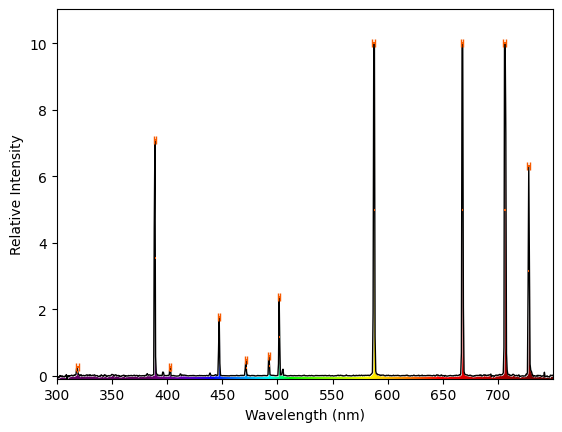

In [474]:
#plt.plot(wavelength, intensity, color ="#BB0000")
clim = (380, 750)
norm = plt.Normalize(*clim)
wl = np.linspace(clim[0], clim[1], len(wavelengths))
colorlist = list(zip(norm(wl), [wavelength_to_rgb(w) for w in wl]))
spectralmap = mcolors.LinearSegmentedColormap.from_list("spectrum", colorlist)

print(spectralmap(0))
X,Y = np.meshgrid(wavelengths, intensities)
extent = (np.min(wavelengths), np.max(wavelengths), np.min(intensities), np.max(intensities))
plt.imshow(X, clim=clim, extent=extent, cmap=spectralmap, aspect='auto')


plt.plot(wavelengths, intensities, color ="black", alpha = 1, lw = 1)

plt.errorbar(wavelengths[peakIndex], intensities[peakIndex], marker ="", color ="#f75b00", xerr = errors, capsize = 3, linestyle ="None", ecolor ="#f75b00", barsabove=False)#b73b00

plt.xlabel("Wavelength (nm)")
plt.ylabel("Relative Intensity")

plt.hlines(width_heights, sample_to_frequency(left_ips), sample_to_frequency(right_ips), color = "#f75b00")


plt.fill_between(wavelengths, intensities, max(intensities * 1.05), color='w')



plt.savefig("plotNeonSpectrum.png", dpi = 300)

plt.show()

In [ ]:
def fill_under_spectrum_vectorized(wavelengths, intensities, wavelength_to_rgb):
    """
    Fill under a spectrum curve using the color associated with each wavelength (hue only),
    fully vectorized for speed.
    """
    # Build vertices for each vertical strip between two wavelength points
    verts = []
    colors = []

    for i in range(len(wavelengths)-1):
        x0, x1 = wavelengths[i], wavelengths[i+1]
        y0, y1 = intensities[i], intensities[i+1]
        verts.append([(x0, 0), (x0, y0), (x1, y1), (x1, 0)])
        colors.append(wavelength_to_rgb(wavelengths[i])[:3])

    # Create PolyCollection
    poly = PolyCollection(verts, facecolors=colors, edgecolors='none')

    # Plot
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.add_collection(poly)
    ax.set_xlim(wavelengths.min(), wavelengths.max())
    ax.set_ylim(0, intensities.max()*1.05)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.set_title("Spectrum filled with wavelength colors (vectorized)")
    plt.show()

def plot_colored_spectrum_line(wavelengths, intensities, wavelength_to_rgb):
    """
    Plot a line where each segment is colored by the wavelength.
    """

    # Build line segments [[(x0,y0),(x1,y1)], [(x1,y1),(x2,y2)], ...]
    points = np.array([wavelengths, intensities]).T
    segments = np.stack([points[:-1], points[1:]], axis=1)

    # Assign a color to each segment based on the wavelength at the left point
    colors = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths[:-1]])

    # Create a LineCollection with the segments and colors
    lc = LineCollection(segments, colors=colors, linewidth=2)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.add_collection(lc)
    ax.set_xlim(wavelengths.min(), wavelengths.max())
    ax.set_ylim(0, intensities.max()*1.05)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.set_title("Spectrum line colored by wavelength")
    plt.show()

def plot_intensity_modulated_spectrum_line(
        wavelengths, intensities, wavelength_to_rgb,
        light_on_high=True, gamma=2.2, smooth_sigma=1.0
    ):
    """
    Plot a spectrum line colored by wavelength with brightness modulated by intensity.
    """

    # Normalize intensities
    inten_norm = mcolors.Normalize(vmin=np.min(intensities), vmax=np.max(intensities))(intensities)

    # Optional gamma contrast
    bright = inten_norm ** gamma

    # Optional smoothing to avoid abrupt jumps
    if smooth_sigma > 0:
        bright = scipy.ndimage.gaussian_filter1d(bright, sigma=smooth_sigma)
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

    # Compute RGB for each wavelength
    base_rgb = np.array([tuple(wavelength_to_rgb(w))[:3] for w in wavelengths])

    # Convert to HSV for brightness modulation
    hsv = mcolors.rgb_to_hsv(base_rgb)
    if light_on_high:
        hsv[:, 2] = bright
    else:
        hsv[:, 2] = 1 - bright
    rgb_modulated = mcolors.hsv_to_rgb(hsv)

    # Build segments for LineCollection
    points = np.array([wavelengths, intensities]).T
    segments = np.stack([points[:-1], points[1:]], axis=1)
    colors = rgb_modulated[:-1]

    # Create LineCollection and plot
    lc = LineCollection(segments, colors=colors, linewidth=2)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.add_collection(lc)
    ax.set_xlim(wavelengths.min(), wavelengths.max())
    ax.set_ylim(0, intensities.max()*1.05)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.set_title("Spectrum line with wavelength hue + intensity brightness")
    plt.show()

def plot_intensity_modulated_spectrum(wavelengths, intensities, wavelength_to_rgb,
                                      light_on_high=True, gamma=2.2, smooth_sigma=1.0):
    """
    Plot a spectrum with:
    - area under the curve filled with intensity-modulated colors
    - line on top colored by wavelength + intensity
    """
    # Normalize intensities
    inten_norm = mcolors.Normalize(vmin=np.min(intensities), vmax=np.max(intensities))(intensities)

    # Apply gamma contrast
    bright = inten_norm ** gamma

    # Smooth brightness to avoid abrupt jumps
    if smooth_sigma > 0:
        bright = scipy.ndimage.gaussian_filter1d(bright, sigma=smooth_sigma)

    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

    # Compute RGB for each wavelength
    base_rgb = np.array([tuple(wavelength_to_rgb(w))[:3] for w in wavelengths])

    # Modulate brightness in HSV
    hsv = mcolors.rgb_to_hsv(base_rgb)
    if light_on_high:
        hsv[:, 2] = bright
    else:
        hsv[:, 2] = 1 - bright
    rgb_modulated = mcolors.hsv_to_rgb(hsv)

    # -------- PolyCollection for filled area --------
    verts = []
    colors_poly = []
    for i in range(len(wavelengths)-1):
        x0, x1 = wavelengths[i], wavelengths[i+1]
        y0, y1 = intensities[i], intensities[i+1]
        verts.append([(x0, 0), (x0, y0), (x1, y1), (x1, 0)])
        colors_poly.append(rgb_modulated[i])
    poly = PolyCollection(verts, facecolors=colors_poly, edgecolors='none')

    # -------- LineCollection for spectrum line --------
    points = np.array([wavelengths, intensities]).T
    segments = np.stack([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, colors=rgb_modulated[:-1], linewidth=2)

    # -------- Plot both --------
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.add_collection(poly)
    ax.add_collection(lc)
    ax.set_xlim(wavelengths.min(), wavelengths.max())
    ax.set_ylim(0, intensities.max()*1.05)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.set_title("Intensity-modulated colored spectrum (filled + line)")
    plt.show()

def plot_spectrum_with_intensity_line(wavelengths, intensities, wavelength_to_rgb,
                                      gamma=2.2, smooth_sigma=1.0):
    """
    Plot a spectrum where:
    - the filled area under the curve is colored by wavelength at full brightness
    - the line on top is intensity-modulated for brightness
    """
    # -------- Full-brightness RGB for filled spectrum --------
    base_rgb = np.array([tuple(wavelength_to_rgb(w))[:3] for w in wavelengths])

    # PolyCollection for filled area (full brightness)
    verts = []
    colors_poly = []
    for i in range(len(wavelengths)-1):
        x0, x1 = wavelengths[i], wavelengths[i+1]
        y0, y1 = intensities[i], intensities[i+1]
        verts.append([(x0, 0), (x0, y0), (x1, y1), (x1, 0)])
        colors_poly.append(base_rgb[i])
    poly = PolyCollection(verts, facecolors=colors_poly, edgecolors='none')

    # -------- Intensity-modulated line --------
    # Normalize intensity
    inten_norm = mcolors.Normalize(vmin=np.min(intensities), vmax=np.max(intensities))(intensities)
    bright = inten_norm ** gamma
    if smooth_sigma > 0:
        bright = scipy.ndimage.gaussian_filter1d(bright, sigma=smooth_sigma)
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

    # Modulate brightness for line only
    hsv_line = mcolors.rgb_to_hsv(base_rgb.copy())
    hsv_line[:, 2] = bright
    rgb_line = mcolors.hsv_to_rgb(hsv_line)

    # LineCollection
    points = np.array([wavelengths, intensities]).T
    segments = np.stack([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, colors=rgb_line[:-1], linewidth=2)

    # -------- Plot both --------
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.add_collection(poly)
    ax.add_collection(lc)
    ax.set_xlim(wavelengths.min(), wavelengths.max())
    ax.set_ylim(0, intensities.max()*1.05)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.set_title("Spectrum (full-brightness) with intensity-modulated line")

    plt.savefig("spectrumplot.png", dpi = 300)
    plt.show()

def plot_spectrum_smooth_fill(wavelengths, intensities, wavelength_to_rgb,
                              gamma=2.2, smooth_sigma=1.0, height=200):
    """
    Smooth, homogeneous spectrum fill using an image.
    The line on top is intensity-modulated; the background fill is full brightness.
    """
    # ---------- Create RGB background (full brightness) ----------
    rgb_bg = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])

    # ---------- Build a 2D image for imshow ----------
    img = np.repeat(rgb_bg[np.newaxis, :, :], height, axis=0)  # shape (height, N, 3)

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(img, extent=[wavelengths.min(), wavelengths.max(), 0, intensities.max()*1.05],
              aspect='auto', origin='lower')

    # ---------- Intensity-modulated line ----------
    # Normalize intensity
    inten_norm = mcolors.Normalize(vmin=np.min(intensities), vmax=np.max(intensities))(intensities)
    bright = inten_norm ** gamma
    if smooth_sigma > 0:
        bright = scipy.ndimage.gaussian_filter1d(bright, sigma=smooth_sigma)
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

    # Modulate brightness for line
    base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
    hsv_line = mcolors.rgb_to_hsv(base_rgb.copy())
    hsv_line[:, 2] = bright
    rgb_line = mcolors.hsv_to_rgb(hsv_line)

    # Plot line
    ax.plot(wavelengths, intensities, color='k', lw=0)  # dummy line for scaling
    for i in range(len(wavelengths)-1):
        ax.plot(wavelengths[i:i+2], intensities[i:i+2], color=rgb_line[i], lw=2)

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.set_title("Spectrum with smooth full-brightness fill and intensity-modulated line")
    plt.show()

def plot_spectrum_fill_under_line(wavelengths, intensities, wavelength_to_rgb,
                                  gamma=2.2, smooth_sigma=1.0, height=200):
    """
    Plot a spectrum with:
    - smooth, full-brightness background under the curve only
    - intensity-modulated line on top
    """
    # ---------- Background RGB image ----------
    rgb_bg = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
    img = np.repeat(rgb_bg[np.newaxis, :, :], height, axis=0)  # shape (height, N, 3)

    # ---------- Build mask so image only shows under curve ----------
    y_grid = np.linspace(0, intensities.max()*1.05, height)[:, None]  # shape (height,1)
    mask = y_grid > intensities[None, :]  # True above the curve
    img_masked = img.copy()
    img_masked[mask] = 1.0  # Set pixels above curve to white (or background color)

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(img_masked, extent=[wavelengths.min(), wavelengths.max(), 0, intensities.max()*1.05],
              aspect='auto', origin='lower')

    # ---------- Intensity-modulated line ----------
    # Normalize intensity
    inten_norm = mcolors.Normalize(vmin=np.min(intensities), vmax=np.max(intensities))(intensities)
    bright = inten_norm ** gamma
    if smooth_sigma > 0:
        bright = scipy.ndimage.gaussian_filter1d(bright, sigma=smooth_sigma)
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

    # Modulate brightness for line only
    base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
    hsv_line = mcolors.rgb_to_hsv(base_rgb.copy())
    hsv_line[:, 2] = bright
    rgb_line = mcolors.hsv_to_rgb(hsv_line)

    # Plot line
    ax.plot(wavelengths, intensities, color='k', lw=0)  # for scaling
    for i in range(len(wavelengths)-1):
        ax.plot(wavelengths[i:i+2], intensities[i:i+2], color=rgb_line[i], lw=2)

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.set_title("Spectrum: smooth fill under curve + intensity-modulated line")
    plt.show()

def plot_spectrum_blended_fill(wavelengths, intensities, wavelength_to_rgb,
                               gamma=2.2, smooth_sigma=1.0, height=200, blend_sigma=1.5):
    """
    Spectrum plot with:
    - full-brightness wavelength background
    - smooth alpha-blended white overlay above the curve (no masking artifacts)
    - intensity-modulated colored line
    """

    # ---------- Make full background image (no masking here) ----------
    rgb_bg = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
    img = np.repeat(rgb_bg[np.newaxis, :, :], height, axis=0)

    ymin, ymax = 0, intensities.max() * 1.05
    y_grid = np.linspace(ymin, ymax, height)[:, None]

    # ---------- Build alpha fade ABOVE the curve ----------
    # alpha = 0 below curve (transparent)
    # alpha = 1 above curve (opaque white)
    alpha = (y_grid > intensities[None, :]).astype(float)

    # Smooth the alpha edge to prevent pixelation
    if blend_sigma > 0:
        alpha = scipy.ndimage.gaussian_filter(alpha, sigma=(blend_sigma, 0))
        alpha = np.clip(alpha, 0, 1)

    # White overlay with alpha channel
    overlay = np.ones((height, len(wavelengths), 4))  # RGBA
    overlay[..., 3] = alpha  # set alpha channel only

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.imshow(img, extent=[wavelengths.min(), wavelengths.max(), ymin, ymax],
              aspect='auto', origin='lower')

    # White transparency that hides everything above the curve
    ax.imshow(overlay, extent=[wavelengths.min(), wavelengths.max(), ymin, ymax],
              aspect='auto', origin='lower')

    # ---------- Intensity-modulated line ----------
    inten_norm = mcolors.Normalize(vmin=np.min(intensities), vmax=np.max(intensities))(intensities)
    bright = inten_norm ** gamma
    if smooth_sigma > 0:
        bright = scipy.ndimage.gaussian_filter1d(bright, sigma=smooth_sigma)
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

    base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
    hsv_line = mcolors.rgb_to_hsv(base_rgb)
    hsv_line[:, 2] = bright
    rgb_line = mcolors.hsv_to_rgb(hsv_line)

    # Draw the full curve invisible for autoscale
    ax.plot(wavelengths, intensities, color='k', lw=0)

    # Draw colored segments
    for i in range(len(wavelengths)-1):
        ax.plot(wavelengths[i:i+2], intensities[i:i+2], color=rgb_line[i], lw=2)

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.set_title("Spectrum: blended fill under curve + intensity-modulated line")

    plt.show()


def plot_spectrum_with_image(
        wavelengths, intensities, wavelength_to_rgb,
        gamma=None,
        gamma_line=None,
        gamma_image=None,
        smooth_sigma=1.0,
        line_width=2.0,
        fill_lower=None,
        fill_enabled=True,
        line_color=None,
        spectrum_height=80,
        vertical_gap=0.08
):
    """
    Plot spectrum line+fill above and horizontal spectrum below, with
    x-axis ticks at the top of the bottom image (shared with top plot).
    """

    import matplotlib.pyplot as plt

    # Handle gamma defaults
    if gamma_line is None and gamma_image is None:
        gamma_line = gamma_image = 2.2 if gamma is None else gamma
    else:
        if gamma_line is None:
            gamma_line = gamma_image
        if gamma_image is None:
            gamma_image = gamma_line

    # ----- Create figure -----
    fig = plt.figure(figsize=(12, 6))

    # Axes positions (fractions of figure)
    top_height = 0.7
    bottom_height = 0.2
    bottom_bottom = 0.1  # distance from bottom

    # Top axes: main spectrum plot
    ax_plot = fig.add_axes([0.08, bottom_bottom + bottom_height + vertical_gap,
                            0.88, top_height])
    # Bottom axes: horizontal spectrum image
    ax_spec = fig.add_axes([0.08, bottom_bottom, 0.88, bottom_height])

    # ----- Top plot: line + fill -----
    plot_spectrum_clip_fill(
        wavelengths=wavelengths,
        intensities=intensities,
        wavelength_to_rgb=wavelength_to_rgb,
        gamma=gamma_line,
        smooth_sigma=smooth_sigma,
        line_width=line_width,
        fill_lower=fill_lower,
        fill_enabled=fill_enabled,
        line_color=line_color,
        ax=ax_plot
    )
    ax_plot.set_xticklabels([])  # hide top x-axis labels
    ax_plot.set_ylabel("Relative Intensity")

    # ----- Bottom plot: horizontal spectrum image -----
    render_spectrum_image(
        wavelengths=wavelengths,
        intensities=intensities,
        wavelength_to_rgb=wavelength_to_rgb,
        gamma=gamma_image,
        ax=ax_spec,
        image_height=spectrum_height
    )

    # ----- Move bottom x-axis ticks to top of bottom axes -----
    ax_spec.xaxis.set_label_position('top')
    ax_spec.xaxis.tick_top()
    ax_spec.set_xlabel("Wavelength (nm)")
    ax_spec.tick_params(axis='x', which='both', direction='out')

    # Align x-limits
    ax_plot.set_xlim(wavelengths.min(), wavelengths.max())
    ax_spec.set_xlim(wavelengths.min(), wavelengths.max())

    # ----- Place title above figure -----
    fig.text(
        0.5, 0.96,
        "Spectrum with fill + horizontal spectrum below",
        ha='center', fontsize=14
    )

    return fig, ax_plot, ax_spec


fig, ax_plot, ax_spec = plot_spectrum_with_image(
    wavelengths=wavelengths,
    intensities=intensities,
    wavelength_to_rgb=wavelength_to_rgb,
    line_width=1,
    fill_enabled=True,
    line_color='black',
    gamma_image=0.5,
)
plt.show()




In [ ]:
def plot_spectrum_combined(
        wavelengths,
        intensities,
        wavelength_to_rgb,
        gamma=2.2,
        smooth_sigma=1.0,
        line_width=2.0,
        fill_lower=None,
        fill_enabled=True,
        line_color=None,
        figsize=(12, 4),
        top_bottom_ratio=4  # ratio of top plot height to bottom image
):
    """
    Plot a combined spectrum figure:
    - Top: intensity vs wavelength line plot with optional colored fill.
    - Bottom: horizontal spectrum image with intensity-based brightness.
    - Shared x-axis, ticks only at the bottom.

    Parameters
    ----------
    wavelengths : array-like
        Wavelengths (nm)
    intensities : array-like
        Relative intensities
    wavelength_to_rgb : callable
        Function mapping wavelength to RGB tuple (0-1)
    gamma : float
        Brightness gamma correction
    smooth_sigma : float
        Smoothing for intensity-modulated line
    line_width : float
        Width of the line in the top plot
    fill_lower : float
        Optional lower bound for fill under the line
    fill_enabled : bool
        Whether to fill with intensity-modulated colors
    line_color : tuple or None
        Fixed color for line (overrides intensity-based coloring)
    figsize : tuple
        Figure size (width, height) in inches
    top_bottom_ratio : float
        Relative height of top plot vs bottom image (default 4)
    """

    # Determine vertical bounds for top plot
    ymin = np.min(intensities) if fill_lower is None else float(fill_lower)
    ymax = intensities.max() * 1.05

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[top_bottom_ratio, 1], hspace=0.05)

    # --- Top: Line plot with optional fill ---
    ax_line = fig.add_subplot(gs[0])

    if fill_enabled:
        rgb_bg = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
        img = np.repeat(rgb_bg[np.newaxis, :, :], 50, axis=0)  # image height in pixels, arbitrary

        verts = np.column_stack([wavelengths, intensities])
        poly = np.concatenate([
            [[wavelengths[0], ymin]],
            verts,
            [[wavelengths[-1], ymin]],
            [[wavelengths[0], ymin]]
        ])
        codes = [Path.MOVETO] + [Path.LINETO] * len(wavelengths) + [Path.LINETO, Path.CLOSEPOLY]
        clip_path = Path(poly, codes)

        im = ax_line.imshow(
            img,
            extent=[wavelengths.min(), wavelengths.max(), ymin, ymax],
            aspect='auto',
            origin='lower'
        )
        im.set_clip_path(clip_path, transform=ax_line.transData)

    # Line plotting
    if line_color is None:
        inten_norm = mcolors.Normalize(vmin=intensities.min(), vmax=intensities.max())(intensities)
        bright = inten_norm ** gamma
        if smooth_sigma > 0:
            bright = scipy.ndimage.gaussian_filter1d(bright, smooth_sigma)
        bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

        base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
        hsv = mcolors.rgb_to_hsv(base_rgb)
        hsv[:, 2] = bright
        rgb_line = mcolors.hsv_to_rgb(hsv)

        for i in range(len(wavelengths) - 1):
            ax_line.plot(wavelengths[i:i + 2], intensities[i:i + 2], color=rgb_line[i], lw=line_width)
    else:
        for i in range(len(wavelengths) - 1):
            ax_line.plot(wavelengths[i:i + 2], intensities[i:i + 2], color=line_color, lw=line_width)

    ax_line.set_xlim(wavelengths.min(), wavelengths.max())
    ax_line.set_ylim(ymin, ymax)
    ax_line.set_ylabel("Intensity")
    ax_line.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # --- Bottom: Horizontal spectrum image ---
    ax_img = fig.add_subplot(gs[1], sharex=ax_line)

    wl_display = np.linspace(wavelengths.min(), wavelengths.max(), 1000)
    inten_display = np.interp(wl_display, wavelengths, intensities)

    # Build intensity-modulated colormap
    inten_norm = mcolors.Normalize(vmin=np.min(inten_display), vmax=np.max(inten_display))(inten_display)
    bright = inten_norm ** gamma
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)
    base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wl_display])
    hsv = mcolors.rgb_to_hsv(base_rgb)
    hsv[:, 2] = bright
    cmap_image = mcolors.ListedColormap(mcolors.hsv_to_rgb(hsv))

    img_data = np.tile(np.arange(len(wl_display)), (20, 1))  # small vertical height
    ax_img.imshow(img_data, cmap=cmap_image, aspect='auto', extent=[wl_display.min(), wl_display.max(), 0, 1])
    ax_img.set_yticks([])
    ax_img.set_xlabel("Wavelength (nm)")

    # Only bottom axis has tick labels
    ax_line.tick_params(axis='x', labelbottom=False)

    return fig, (ax_line, ax_img)


fig, (ax_plot, ax_spec) = plot_spectrum_combined(
    wavelengths=wavelengths,
    intensities=intensities,
    wavelength_to_rgb=wavelength_to_rgb,
    line_width=1,
    fill_enabled=True,
    line_color='black',
    gamma=0.5,
)

ax_plot.errorbar(wavelengths[peakIndex], intensities[peakIndex], marker="", color="#f75b00", xerr=errors, capsize=3,
                 linestyle="None", ecolor="#f75b00", barsabove=False)  #b73b00
plt.show()


In [ ]:
def plot_spectrum_combined_middle_ticks_consistent_labels(
        wavelengths,
        intensities,
        wavelength_to_rgb,
        gamma=2.2,
        smooth_sigma=1.0,
        line_width=2.0,
        fill_lower=None,
        fill_enabled=True,
        line_color=None,
        figsize=(12, 4),
        top_bottom_ratio=4,
        num_ticks=5,
        vertical_spacing=0.25,
        tick_format="{:.0f}"  # formatting string for both middle and bottom ticks
):
    """
    Plot combined spectrum figure:
    - Top: intensity vs wavelength line plot
    - Bottom: horizontal spectrum image with bottom ticks and labels
    - Middle: tick labels centered, with two short ticks per x-location
      (one touching the top plot, one touching the bottom plot)
    - Bottom axes ticks aligned with middle ticks
    - Tick labels use the same format for consistency
    """

    ymin = np.min(intensities) if fill_lower is None else float(fill_lower)
    ymax = intensities.max() * 1.05

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[top_bottom_ratio, 1], hspace=vertical_spacing)

    # --- Top: line plot ---
    ax_line = fig.add_subplot(gs[0])
    if fill_enabled:
        rgb_bg = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
        img = np.repeat(rgb_bg[np.newaxis, :, :], 50, axis=0)
        verts = np.column_stack([wavelengths, intensities])
        poly = np.concatenate([
            [[wavelengths[0], ymin]],
            verts,
            [[wavelengths[-1], ymin]],
            [[wavelengths[0], ymin]]
        ])
        codes = [Path.MOVETO] + [Path.LINETO] * len(wavelengths) + [Path.LINETO, Path.CLOSEPOLY]
        clip_path = Path(poly, codes)
        im = ax_line.imshow(
            img,
            extent=[wavelengths.min(), wavelengths.max(), ymin, ymax],
            aspect='auto',
            origin='lower'
        )
        im.set_clip_path(clip_path, transform=ax_line.transData)

    if line_color is None:
        inten_norm = mcolors.Normalize(vmin=intensities.min(), vmax=intensities.max())(intensities)
        bright = inten_norm ** gamma
        if smooth_sigma > 0:
            bright = scipy.ndimage.gaussian_filter1d(bright, smooth_sigma)
        bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)
        base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
        hsv = mcolors.rgb_to_hsv(base_rgb)
        hsv[:, 2] = bright
        rgb_line = mcolors.hsv_to_rgb(hsv)
        for i in range(len(wavelengths) - 1):
            ax_line.plot(wavelengths[i:i + 2], intensities[i:i + 2], color=rgb_line[i], lw=line_width)
    else:
        for i in range(len(wavelengths) - 1):
            ax_line.plot(wavelengths[i:i + 2], intensities[i:i + 2], color=line_color, lw=line_width)

    ax_line.set_xlim(wavelengths.min(), wavelengths.max())
    ax_line.set_ylim(ymin, ymax)
    ax_line.set_ylabel("Intensity")
    ax_line.tick_params(axis='x', bottom=False, top=False, labelbottom=False)

    # --- Bottom: spectrum image ---
    ax_img = fig.add_subplot(gs[1], sharex=ax_line)
    wl_display = np.linspace(wavelengths.min(), wavelengths.max(), 1000)
    inten_display = np.interp(wl_display, wavelengths, intensities)
    inten_norm = mcolors.Normalize(vmin=np.min(inten_display), vmax=np.max(inten_display))(inten_display)
    bright = inten_norm ** gamma
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)
    base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wl_display])
    hsv = mcolors.rgb_to_hsv(base_rgb)
    hsv[:, 2] = bright
    cmap_image = mcolors.ListedColormap(mcolors.hsv_to_rgb(hsv))
    img_data = np.tile(np.arange(len(wl_display)), (20, 1))
    ax_img.imshow(img_data, cmap=cmap_image, aspect='auto', extent=[wl_display.min(), wl_display.max(), 0, 1])
    ax_img.set_yticks([])
    ax_img.set_xlabel("Wavelength (nm)")

    # --- Middle ticks and labels ---
    tick_locations = np.linspace(wavelengths.min(), wavelengths.max(), num_ticks)

    # Align bottom axes ticks with middle ticks and show labels
    ax_img.set_xticks(tick_locations)
    # Use tick labels formatted like middle ticks
    tick_labels = [tick_format.format(x) for x in tick_locations]
    ax_img.set_xticklabels(tick_labels)
    ax_img.tick_params(axis='x', labelbottom=True)

    top_pos = ax_line.get_position()
    bottom_pos = ax_img.get_position()
    middle_y = (top_pos.y0 + bottom_pos.y1) / 2  # center of the space between axes

    for x in tick_locations:
        # Convert data x to figure coordinates
        x_fig = ax_line.transData.transform((x, 0))[0]
        x_fig_rel = (x_fig - fig.bbox.x0) / fig.bbox.width

        # Tick from top plot downwards
        fig.lines.append(plt.Line2D([x_fig_rel, x_fig_rel], [top_pos.y0, top_pos.y0 - 0.02],
                                    transform=fig.transFigure, color='k', lw=1))
        # Tick from bottom plot upwards
        fig.lines.append(plt.Line2D([x_fig_rel, x_fig_rel], [bottom_pos.y1, bottom_pos.y1 + 0.02],
                                    transform=fig.transFigure, color='k', lw=1))
        # Label in the middle
        fig.text(x_fig_rel, middle_y, tick_format.format(x), ha='center', va='center', fontsize=10)

    return fig, (ax_line, ax_img)


fig, (ax_plot, ax_spec) = plot_spectrum_combined_middle_ticks_consistent_labels(
    wavelengths=wavelengths,
    intensities=intensities,
    wavelength_to_rgb=wavelength_to_rgb,
    line_width=1,
    fill_enabled=True,
    line_color=None,
    gamma=0.5,
    vertical_spacing=0.3,
    top_bottom_ratio=4,
    num_ticks=10
)

ax_plot.errorbar(wavelengths[peakIndex], intensities[peakIndex], marker="", color="#f75b00", xerr=errors, capsize=3,
                 linestyle="None", ecolor="#f75b00", barsabove=False)  #b73b00
plt.show()

In [ ]:
#cmap_lineplot = make_wavelength_intensity_cmap(wavelengths, intensities, wavelength_to_rgb, smooth_sigma=5, gamma = 0.000001)
#fill_under_spectrum_vectorized(wavelengths, intensities, wavelength_to_rgb)
#plot_colored_spectrum_line(wavelengths, intensities, wavelength_to_rgb)
#plot_intensity_modulated_spectrum_line(wavelengths, intensities, wavelength_to_rgb,gamma = 0.5, smooth_sigma = 6)